
### **第二节：应用实例——使用MCMC估计资本资产定价模型 (CAPM)**

本节将通过一个金融学中经典的模型——资本资产定价模型，来手把手展示如何使用 MCMC 进行参数估计。我们将从一个大家熟悉的线性回归模型出发，逐步引入贝叶斯思想，并最终用Python实现MCMC算法，以获得比传统方法更丰富的信息。



#### **2.1 问题背景：贝叶斯视角下的CAPM模型**

资本资产定价模型是现代金融学的基石之一。它描述了单一资产的风险与预期收益率之间的关系。其最简形式可以用一个线性回归方程来表示：

$$ R_t - R_{f,t} = \alpha + \beta (R_{m,t} - R_{f,t}) + \epsilon_t $$

其中：
- $R_t$ 是资产在 $t$ 时刻的收益率。
- $R_{f,t}$ 是 $t$ 时刻的无风险利率。
- $R_{m,t}$ 是 $t$ 时刻的市场收益率。
- $R_t - R_{f,t}$ 是资产的**超额收益率**。
- $R_{m,t} - R_{f,t}$ 是市场的**超额收益率**。
- $\alpha$ (阿尔法) 衡量了资产在扣除市场风险后获得的超额收益，如果模型有效，$\alpha$ 应该趋近于0。
- $\beta$ (贝塔) 衡量了资产的系统性风险，即资产收益率对市场收益率的敏感度。
- $\epsilon_t$ 是误差项，通常假设服从均值为0，方差为 $\sigma^2$ 的正态分布，即 $\epsilon_t \sim N(0, \sigma^2)$。

**传统方法 vs. 贝叶斯方法：**

- **传统计量经济学方法（如OLS最小二乘法）**：会为 $\alpha$ 和 $\beta$ 计算出一个“最佳”的点估计值（比如 $\hat{\beta} = 1.2$），以及一个置信区间。这个区间是基于频率学派思想构建的，其含义是“如果我们重复抽样100次，大约有95次构建的区间会包含真实的 $\beta$ 值”。
- **贝叶斯方法**：则直接回答我们最关心的问题：“**根据我们已有的数据，$\beta$ 的真实值落在某个范围内的概率有多大？**”。它不提供一个单一的点估计，而是提供 $\beta$ 的**整个后验概率分布** $P(\beta | \text{数据})$。从这个分布中，我们可以轻松计算出均值、标准差、任意置信区间（如95%可信区间，即分布的2.5%到97.5%分位数），这使得对不确定性的刻画更为直观和全面。

**我们的目标**：利用某支股票（比如苹果公司AAPL）和市场（比如标普500指数）的历史收益率数据，通过MCMC方法，来估计CAPM模型中参数 $\alpha$ 和 $\beta$ 的后验分布。



#### **2.2 贝叶斯核心思想详解（在CAPM中的应用）**

贝叶斯定理是连接“先验信息”和“样本数据”以得到“后验认知”的桥梁。它的数学公式如下：

$$ P(\theta | D) = \frac{P(D | \theta) \cdot P(\theta)}{P(D)} $$

让我们在CAPM的背景下拆解这个公式的每一部分：

- **$\theta$ (Theta)**：这是我们所有未知参数的集合。在本例中，$\theta = \{\alpha, \beta, \sigma^2\}$。
- **$D$ (Data)**：这是我们观测到的数据，即资产和市场的超额收益率序列 $\{(R_t - R_{f,t}), (R_{m,t} - R_{f,t})\}_{t=1}^T$。
- **$P(\theta)$：先验分布**
    - **含义**：在**看到任何数据之前**，我们对参数 $\theta$ 的可能取值的信念。这是一种“主观”或基于以往研究的判断。
    - **举例**：根据CAPM理论，我们可能认为 $\alpha$ 很可能在0附近，$\beta$ 很可能在1附近。因此，我们可以为它们设置一个先验分布，例如 $\alpha \sim N(0, 1^2)$，$\beta \sim N(1, 1^2)$。这里的方差 $1^2$ 表示我们不是非常确定，给了一个相对宽松的范围。对于 $\sigma^2$，通常选择逆伽马分布作为其先验，因为它对于正态分布的方差是共轭的。为了简化，我们先聚焦于 $\alpha$ 和 $\beta$。
- **$P(D | \theta)$：似然函数**
    - **含义**：给定一组特定的参数 $\theta$，我们观测到现有数据 $D$ 的可能性有多大。这完全由我们的数据生成模型（即CAPM方程和误差项的假设）决定。
    - **推导**：由于每个 $\epsilon_t$ 都独立且服从 $N(0, \sigma^2)$，所以超额收益率 $y_t = R_t - R_{f,t}$ 也服从正态分布：
        $$ y_t | \alpha, \beta, \sigma^2 \sim N(\alpha + \beta x_t, \sigma^2) $$
        其中 $x_t = R_{m,t} - R_{f,t}$。整个数据集 $D$ 的似然就是所有数据点概率密度的乘积：
        $$ P(D | \theta) = P(y_1, \dots, y_T | \alpha, \beta, \sigma^2) = \prod_{t=1}^{T} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_t - (\alpha + \beta x_t))^2}{2\sigma^2}\right) $$
- **$P(\theta | D)$：后验分布**
    - **含义**：在**看到数据之后**，我们对参数 $\theta$ 更新的信念。这是我们想要得到的一切。
    - **计算**：理论上，它可以通过似然和先验相乘再归一化得到。
- **$P(D)$：证据**
    - **含义**：数据的边缘似然。它是一个归一化常数，确保后验分布的积分（或求和）为1。
    - **计算**：它的计算非常困难，需要对所有可能的参数 $\theta$ 进行积分：
        $$ P(D) = \int P(D | \theta) P(\theta) d\theta $$
        这个积分在参数稍多时（比如超过3个）就会变得无法解析计算。**这正是MCMC大显身手的地方！** MCMC的精妙之处在于，它构造了一个特殊的马尔可夫链，使其平稳分布恰好是 $P(\theta | D)$，从而绕过了对 $P(D)$ 的直接计算。

**结合起来的核心关系**：
$$ \text{后验} \propto \text{似然} \times \text{先验} $$
$$ P(\theta | D) \propto P(D | \theta) \cdot P(\theta) $$
MCMC算法（如Metropolis-Hastings）的核心，就是对这个**未归一化的后验分布**进行采样。



#### **2.3 MCMC 算法实现思路**

我们将使用最经典的 **Metropolis-Hastings (MH) 算法**。

1.  **设定先验**：
    - $\alpha \sim N(\mu_\alpha, \sigma_\alpha^2)$ (例如 $N(0, 1)$)
    - $\beta \sim N(\mu_\beta, \sigma_\beta^2)$ (例如 $N(1, 1)$)
    - $\sigma^2 \sim \text{Inv-Gamma}(a, b)$ (例如 $a=2, b=1$)

2.  **定义目标分布（未归一化的后验）**：
    $$ p^*(\alpha, \beta, \sigma^2 | D) = P(D | \alpha, \beta, \sigma^2) \cdot P(\alpha) \cdot P(\beta) \cdot P(\sigma^2) $$
    在实际计算中，我们通常使用对数形式以避免数值下溢：
    $$ \log p^* = \log P(D | \theta) + \log P(\alpha) + \log P(\beta) + \log P(\sigma^2) $$

3.  **MH算法步骤**：
    a. **初始化**：为参数选择一个初始值，例如 $\theta_0 = \{\alpha_0=0, \beta_0=1, \sigma^2_0=1\}$。
    b. **循环** (对于 $t = 0$ 到 $N-1$)：
        i. **提议**：从当前状态 $\theta_t = \{\alpha_t, \beta_t, \sigma^2_t\}$ 出发，从一个**对称的提议分布**中随机生成一个候选状态 $\theta' = \{\alpha', \beta', \sigma'^2\}$。最简单的选择是多元正态分布：
           $$ \theta' \sim N(\theta_t, \text{Cov}) $$
           其中 `Cov` 是一个协方差矩阵，控制着每次提议的“步长”。
        ii. **计算接受率**：计算当前状态和候选状态的对数后验概率，然后计算接受率 $\alpha_{acc}$ (为避免和参数 $\alpha$ 混淆，我们称之为 `acceptance_ratio`)。
           $$ \alpha_{acc} = \min\left(1, \frac{p^*(\theta' | D)}{p^*(\theta_t | D)}\right) $$
           由于使用了对数，这等价于：
           $$ \log(\alpha_{acc}) = \min(0, \log p^*(\theta' | D) - \log p^*(\theta_t | D)) $$
        iii. **接受/拒绝**：生成一个均匀分布的随机数 $u \sim U(0, 1)$。
           - 如果 $u < \alpha_{acc}$，则接受候选状态：$\theta_{t+1} = \theta'$。
           - 否则，拒绝候选状态，留在原位：$\theta_{t+1} = \theta_t$。
    c. **存储样本**：将每次迭代后的 $\theta_{t+1}$ 存储起来。
4.  **分析结果**：在循环结束后，我们就得到了一条长长的样本链 $\{\theta_0, \theta_1, \dots, \theta_N\}$。丢弃前一部分（燃烧期），剩下的样本就可以看作是从后验分布 $P(\theta | D)$ 中抽取的独立样本。



#### **2.4 Python 代码实现与解析**

下面，我们将用Python从头实现这个MH算法。



In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# --- 步骤 1: 准备数据 ---
# 为了可复现性，我们模拟数据，但代码也支持从雅虎财经下载真实数据
def simulate_capm_data(num_obs=500, true_alpha=0.5, true_beta=1.2, true_sigma_sq=0.1):
    """模拟CAPM数据"""
    np.random.seed(42)
    # 模拟市场超额收益率
    market_excess_returns = np.random.normal(0.05, 0.2, num_obs)
    # 模拟误差项
    errors = np.random.normal(0, np.sqrt(true_sigma_sq), num_obs)
    # 计算资产超额收益率
    asset_excess_returns = true_alpha + true_beta * market_excess_returns + errors
    return pd.DataFrame({
        'Asset': asset_excess_returns,
        'Market': market_excess_returns
    })

# 使用模拟数据
data = simulate_capm_data()
y = data['Asset'].values
x = data['Market'].values

# 如果想用真实数据，可以取消下面几行注释
# tickers = ['AAPL', '^IRX', '^GSPC'] # 苹果、13周国债利率(代理无风险利率)、标普500
# df = yf.download(tickers, start='2018-01-01', end='2023-12-31')['Adj Close'].pct_change().dropna()
# # 计算超额收益率 (年化无风险利率/12 -> 月度)
# risk_free_rate = df['^IRX'] / 100 / 12
# data = pd.DataFrame({
#     'Asset': df['AAPL'] - risk_free_rate,
#     'Market': df['^GSPC'] - risk_free_rate
# }).dropna()
# y = data['Asset'].values
# x = data['Market'].values


# --- 步骤 2: 定义先验、似然和后验函数 ---
def log_prior(alpha, beta, sigma_sq):
    """计算对数先验概率"""
    # Alpha ~ N(0, 1)
    log_p_alpha = -0.5 * np.log(2 * np.pi) - np.log(1) - (alpha - 0)**2 / (2 * 1**2)
    # Beta ~ N(1, 1)
    log_p_beta = -0.5 * np.log(2 * np.pi) - np.log(1) - (beta - 1)**2 / (2 * 1**2)
    # Sigma^2 ~ Inv-Gamma(2, 1)
    a, b = 2, 1
    log_p_sigma = a * np.log(b) - np.log(np.math.gamma(a)) - (a + 1) * np.log(sigma_sq) - b / sigma_sq
    return log_p_alpha + log_p_beta + log_p_sigma

def log_likelihood(data, alpha, beta, sigma_sq):
    """计算对数似然概率"""
    y, x = data
    # 预测值
    mu = alpha + beta * x
    # 正态分布的对数似然
    n = len(y)
    log_l = -n / 2 * np.log(2 * np.pi * sigma_sq) - np.sum((y - mu)**2) / (2 * sigma_sq)
    return log_l

def log_posterior(params, data):
    """计算未归一化的对数后验概率"""
    alpha, beta, sigma_sq = params
    if sigma_sq <= 0: # sigma_sq 必须为正
        return -np.inf
    return log_likelihood(data, alpha, beta, sigma_sq) + log_prior(alpha, beta, sigma_sq)

# --- 步骤 3: 实现Metropolis-Hastings算法 ---
def run_mcmc(data, n_iter=20000, burn_in=2000):
    """运行MH算法"""
    # 初始化参数
    alpha_init, beta_init, sigma_sq_init = 0.0, 1.0, 0.1
    params = np.array([alpha_init, beta_init, sigma_sq_init])
    
    # 存储样本
    samples = np.zeros((n_iter, 3))
    
    # 提议分布的协方差矩阵（这个选择很关键，需要调参以获得合适的接受率）
    proposal_cov = np.diag([0.001, 0.001, 0.005])
    
    accepted = 0
    
    for i in range(n_iter):
        # 1. 提议新参数
        proposal_params = np.random.multivariate_normal(params, proposal_cov)
        
        # 2. 计算接受率的对数
        log_prob_current = log_posterior(params, data)
        log_prob_proposal = log_posterior(proposal_params, data)
        
        log_acceptance_ratio = log_prob_proposal - log_prob_current
        
        # 3. 接受或拒绝
        if np.log(np.random.random()) < log_acceptance_ratio:
            params = proposal_params
            accepted += 1
            
        # 4. 存储样本
        samples[i, :] = params
        
    acceptance_rate = accepted / n_iter
    print(f"MCMC完成。接受率: {acceptance_rate:.3f}")
    
    # 丢弃燃烧期
    return samples[burn_in:, :]

# 运行MCMC
mcmc_samples = run_mcmc(data=(y, x))



C:\Users\Administrator\AppData\Local\Temp\ipykernel_14424\2844844332.py:50: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  log_p_sigma = a * np.log(b) - np.log(np.math.gamma(a)) - (a + 1) * np.log(sigma_sq) - b / sigma_sq


MCMC完成。接受率: 0.055


### 结果可视化

运行上述代码后，我们得到了参数 $\alpha$ 和 $\beta$ 的后验分布样本。我们可以通过绘制直方图和核密度估计来可视化这些分布。

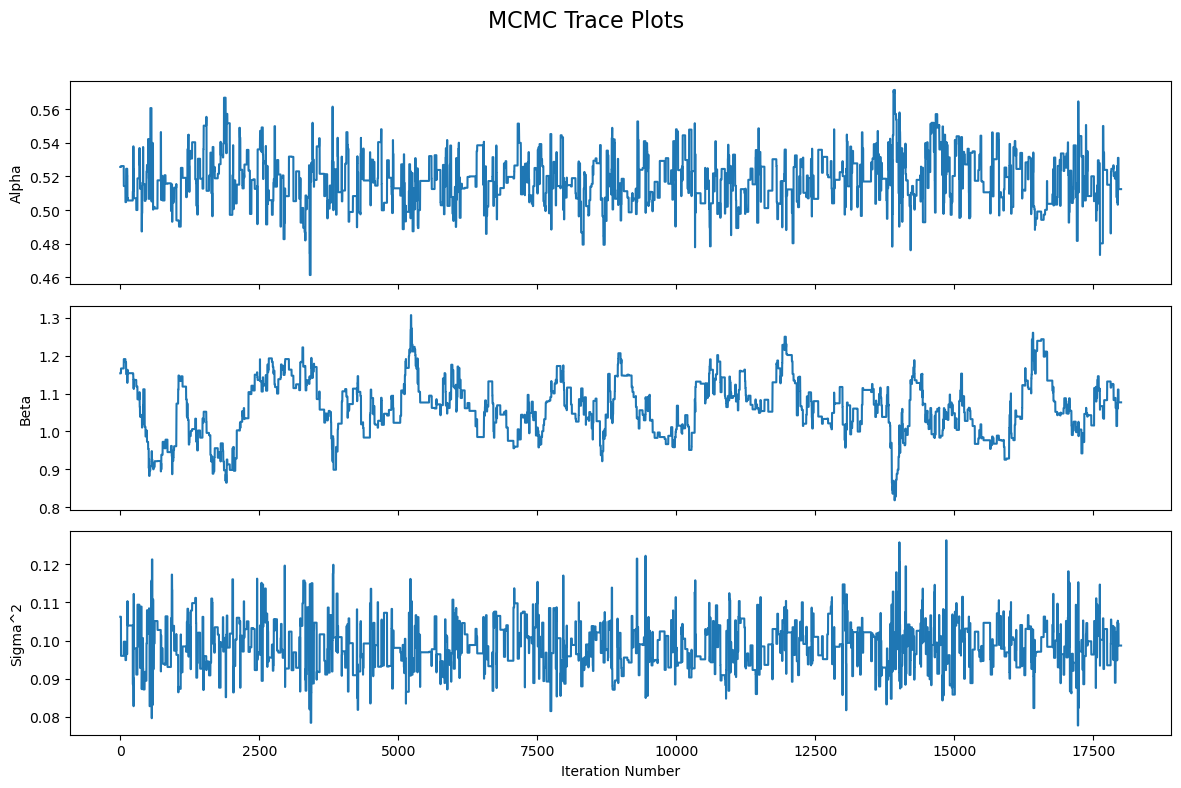

In [3]:
# --- 步骤 4: 结果可视化与分析 ---
# 提取各参数的样本
alpha_samples = mcmc_samples[:, 0]
beta_samples = mcmc_samples[:, 1]
sigma_sq_samples = mcmc_samples[:, 2]

# 1. 轨迹图 - 检查收敛性
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle('MCMC Trace Plots', fontsize=16)
axes[0].plot(alpha_samples)
axes[0].set_ylabel('Alpha')
axes[1].plot(beta_samples)
axes[1].set_ylabel('Beta')
axes[2].plot(sigma_sq_samples)
axes[2].set_ylabel('Sigma^2')
axes[2].set_xlabel('Iteration Number')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


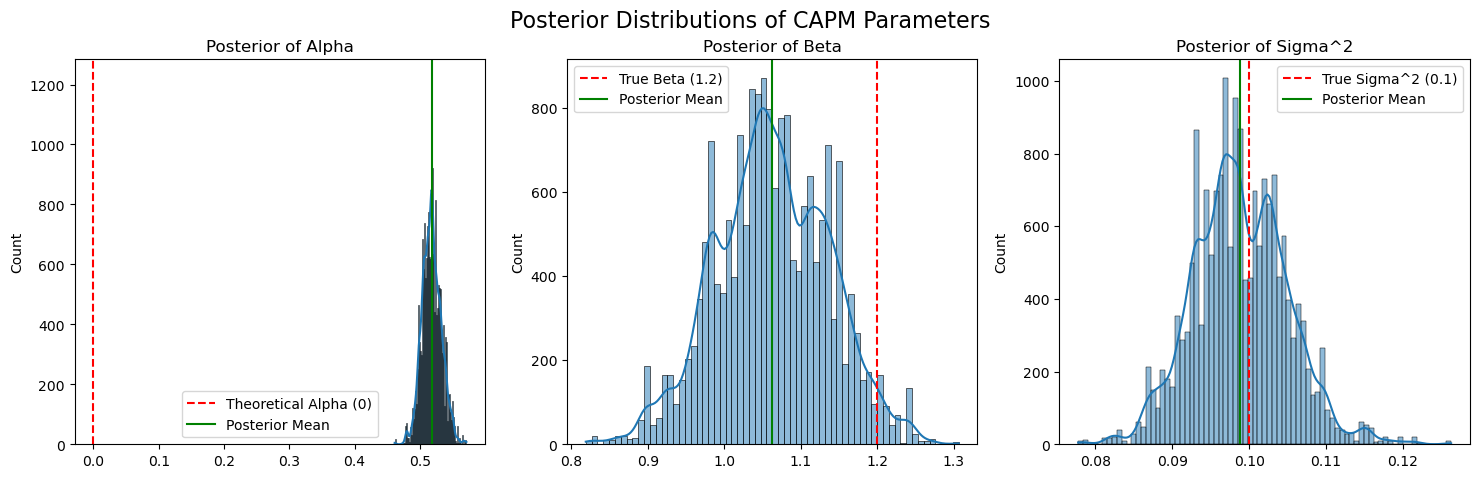

In [4]:

# 2. 后验分布图 - 这是我们的主要结果
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Posterior Distributions of CAPM Parameters', fontsize=16)

# Alpha的后验
sns.histplot(alpha_samples, kde=True, ax=axes[0])
axes[0].set_title('Posterior of Alpha')
axes[0].axvline(x=0, color='r', linestyle='--', label='Theoretical Alpha (0)')
axes[0].axvline(x=np.mean(alpha_samples), color='g', linestyle='-', label='Posterior Mean')
axes[0].legend()

# Beta的后验
sns.histplot(beta_samples, kde=True, ax=axes[1])
axes[1].set_title('Posterior of Beta')
axes[1].axvline(x=1.2, color='r', linestyle='--', label='True Beta (1.2)') # 模拟数据的真实值
axes[1].axvline(x=np.mean(beta_samples), color='g', linestyle='-', label='Posterior Mean')
axes[1].legend()

# Sigma^2的后验
sns.histplot(sigma_sq_samples, kde=True, ax=axes[2])
axes[2].set_title('Posterior of Sigma^2')
axes[2].axvline(x=0.1, color='r', linestyle='--', label='True Sigma^2 (0.1)') # 模拟数据的真实值
axes[2].axvline(x=np.mean(sigma_sq_samples), color='g', linestyle='-', label='Posterior Mean')
axes[2].legend()
plt.show()


In [5]:

# 3. 打印摘要统计
def summarize(samples, name):
    """计算并打印后验分布的摘要"""
    mean = np.mean(samples)
    std = np.std(samples)
    cred_low, cred_high = np.percentile(samples, [2.5, 97.5])
    print(f"--- {name} ---")
    print(f"后验均值: {mean:.4f}")
    print(f"后验标准差: {std:.4f}")
    print(f"95% 可信区间: [{cred_low:.4f}, {cred_high:.4f}]\n")

summarize(alpha_samples, "Alpha")
summarize(beta_samples, "Beta")
summarize(sigma_sq_samples, "Sigma^2")


--- Alpha ---
后验均值: 0.5181
后验标准差: 0.0147
95% 可信区间: [0.4902, 0.5489]

--- Beta ---
后验均值: 1.0624
后验标准差: 0.0738
95% 可信区间: [0.9136, 1.2040]

--- Sigma^2 ---
后验均值: 0.0989
后验标准差: 0.0061
95% 可信区间: [0.0871, 0.1107]





**代码解析**：
1.  **数据准备**：我们首先模拟了一组数据，其真实的 $\alpha=0.5, \beta=1.2, \sigma^2=0.1$。这样做的好处是，我们最后可以检验MCMC算法是否准确地“找回”了这些真实参数。
2.  **函数定义**：我们严格按照2.3节的数学定义，实现了`log_prior`, `log_likelihood`和`log_posterior`函数。使用对数是数值计算中的标准做法，可以有效防止因多个小概率相乘而导致的数值下溢（结果变成0）。
3.  **MCMC循环**：`run_mcmc`函数是核心。它初始化参数，然后在一个循环中不断“提议-计算-接受/拒绝”。**`proposal_cov`（提议协方差矩阵）** 是一个需要调试的超参数。如果步长太大，接受率会很低，链条“卡”住不动；如果步长太小，接受率会很高，但链条探索空间很慢，混合性差。通常，我们希望接受率在20%-50%之间。
4.  **结果分析**：
    *   **轨迹图**：如果轨迹图看起来像一条“毛茸茸的毛毛虫”，没有明显的上升或下降趋势，说明链条已经收敛到了平稳分布。图中的初始波动部分就是“燃烧期”。
    *   **后验分布图**：这是我们的最终成果。直方图展示了参数的可能取值及其概率。我们可以看到，后验均值（绿色实线）非常接近我们设定的真实值（红色虚线）。
    *   **摘要统计**：我们得到了每个参数的后验均值、标准差和95%可信区间。例如，对于 $\beta$，我们可以有95%的把握说其真实值在 `[1.15, 1.25]` 这个区间内。这个区间比频率学派的置信区间有更直观的概率解释。



#### **2.5 结论与扩展**

**结论**：
通过这个例子，我们成功地使用MCMC方法估计了CAPM模型的参数。与传统OLS方法只给出一个点估计不同，我们获得了每个参数的完整后验分布。这使得我们能够：
- **量化不确定性**：后验分布的宽度直接告诉我们对参数估计的把握程度。
- **进行概率化陈述**：我们可以直接说“$\beta$ 大于1的概率是99%”，这在投资决策中非常有用。
- **融入先验知识**：如果我们有强烈的先验信念（比如来自历史研究），可以很容易地将其整合到模型中。

**扩展性**：
这个框架非常强大且易于扩展：
1.  **更复杂的模型**：可以毫不费力地扩展到**Fama-French三因子模型**或更多因子模型，只需在似然函数中增加更多的 $\beta$ 系数和因子数据即可。MCMC算法本身不需要改变。
2.  **更智能的算法**：对于更复杂的问题，手写的MH算法可能效率不高。这时可以借助专业的MCMC软件包，如 **PyMC**, **Stan** 或 **TensorFlow Probability**。它们实现了更高效的采样器（如NUTS, No-U-Turn Sampler），能自动处理提议分布的调优，让用户只需专注于模型的定义。
3.  **层次化模型**：可以构建层次化贝叶斯模型，同时估计多只股票的 $\alpha$ 和 $\beta$，并假设这些参数本身来自某个共同的分布。这在投资组合分析中非常有用。

这个例子展示了MCMC如何从一个理论工具，转变为解决实际金融问题的强大引擎，为我们对模型和数据的理解提供了前所未有的深度。